# Environmental Science Lab
## Training exercise - statistical distributions

** Student given and family name: ** 

** Date: dd.mm.yyyy ** 

---
## 1) Objective
Measure a series of values that are statistically distributed, compute their frequency of occurrence, compute their PDF and plot it

## 2) Experimental Setup
- ...

## 3) Procedure
- ...

---
## 4) Enter Your Data
Enter measurements...


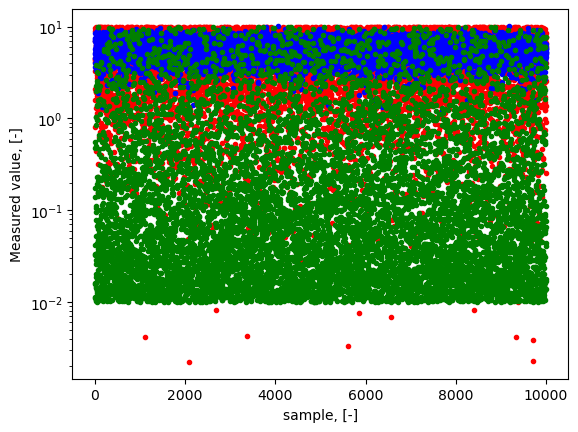

4.961725771528781
5.677285085037509
0.6341690433755429


In [12]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng()

N = 10000

# Uniformly distributed values
a = 0
b = 10
X1 = rng.uniform(a, b, N)

# Normally distributed values
mu = 5.67
s = 1.23
X2 = rng.normal(mu, s, N)

# power-law (Pareto) distributed values
xmin = 0.01
xmax = 10
alpha = 1.3
u = np.random.random(N)
X3 = ( (xmax**(1-alpha) - xmin**(1-alpha)) * u + xmin**(1-alpha) )**(1/(1-alpha))

plt.figure(1)
plt.semilogy(X1, 'r.')
plt.semilogy(X2, 'b.')
plt.semilogy(X3, 'g.')
plt.xlabel("sample, [-]")
plt.ylabel("Measured value, [-]")
plt.show()

print(np.sum(X1)/N)
print(np.sum(X2)/N)
print(np.sum(X3)/N)

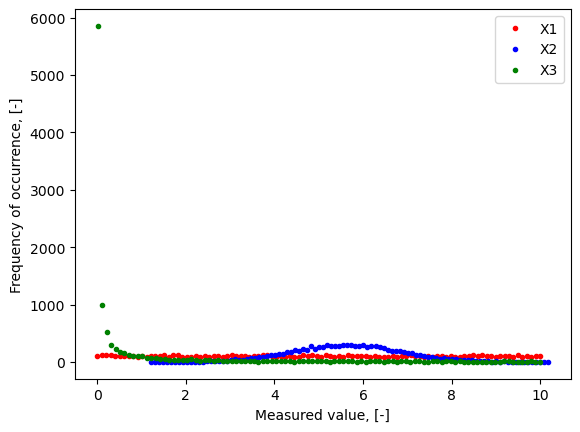

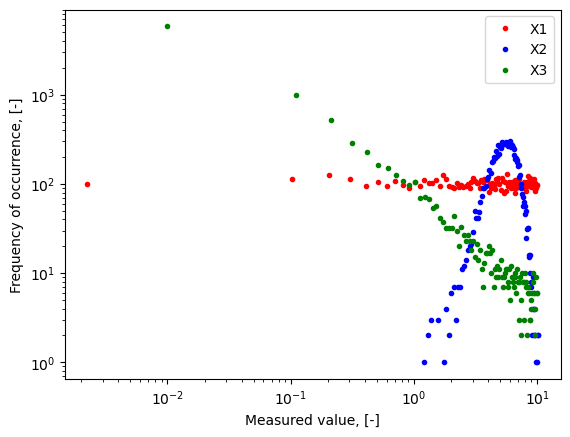

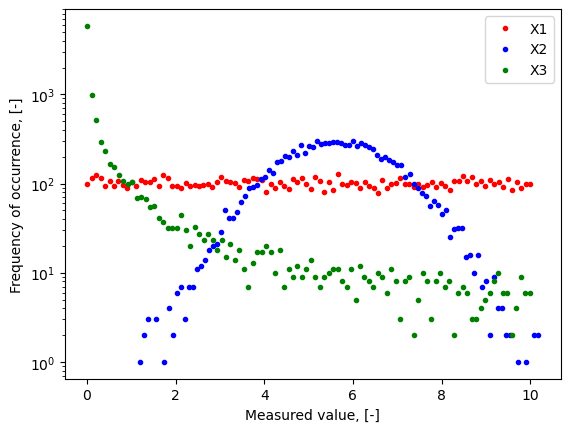

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# bin edges
n = 100
x1 = np.linspace(X1.min(), X1.max(), n)
x2 = np.linspace(X2.min(), X2.max(), n)
x3 = np.linspace(X3.min(), X3.max(), n)

# histograms
F1, edges1 = np.histogram(X1, bins=x1)
F1 = np.append(F1, F1[-1])
F2, edges2 = np.histogram(X2, bins=x2)
F2 = np.append(F2, F2[-1])
F3, edges3 = np.histogram(X3, bins=x3)
F3 = np.append(F3, F3[-1])

plt.figure(1)
plt.plot(x1, F1, 'r.', label='X1')
plt.plot(x2, F2, 'b.', label='X2')
plt.plot(x3, F3, 'g.', label='X3')
plt.ylabel("Frequency of occurrence, [-]")
plt.xlabel("Measured value, [-]")
plt.legend()
plt.show()

plt.figure(2)
plt.loglog(x1, F1, 'r.', label='X1')
plt.loglog(x2, F2, 'b.', label='X2')
plt.loglog(x3, F3, 'g.', label='X3')
plt.ylabel("Frequency of occurrence, [-]")
plt.xlabel("Measured value, [-]")
plt.legend()
plt.show()

plt.figure(3)
plt.semilogy(x1, F1, 'r.', label='X1')
plt.semilogy(x2, F2, 'b.', label='X2')
plt.semilogy(x3, F3, 'g.', label='X3')
plt.ylabel("Frequency of occurrence, [-]")
plt.xlabel("Measured value, [-]")
plt.legend()
plt.show()


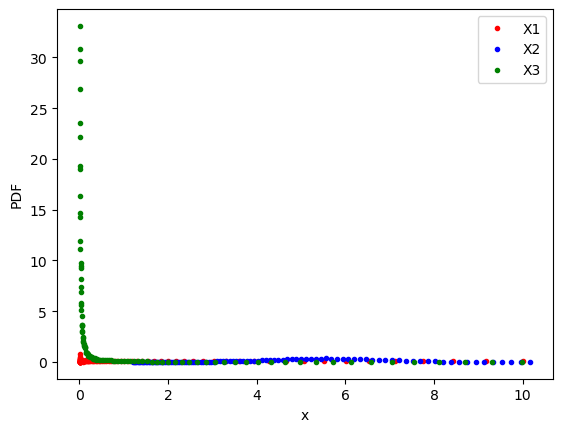

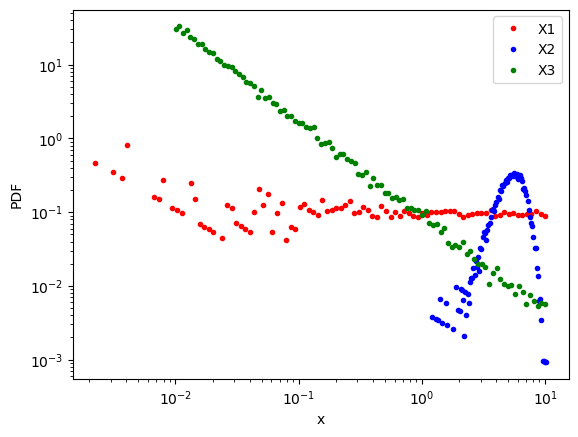

1.0
0.9999999999999999
1.0


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform, norm

# bin edges
n = 100
#x1 = np.linspace(X1.min(), X1.max(), n)
#x2 = np.linspace(X2.min(), X2.max(), n)
x1 = np.logspace(np.log10(X1.min()), np.log10(X1.max()),n)
x2 = np.logspace(np.log10(X2.min()), np.log10(X2.max()),n)
x3 = np.logspace(np.log10(X3.min()), np.log10(X3.max()),n)

# histograms
F1, edges1 = np.histogram(X1, bins=x1)
F1 = np.append(F1, F1[-1])
F2, edges2 = np.histogram(X2, bins=x2)
F2 = np.append(F2, F2[-1])
F3, edges3 = np.histogram(X3, bins=x3)
F3 = np.append(F3, F3[-1])

dx1 = np.gradient(x1)
dx2 = np.gradient(x2)
dx3 = np.gradient(x3)

# compute normalized histogram for X1
H1 = F1 / dx1
pdf1 = H1 / np.sum(H1 * dx1)

# compute normalized histogram for X2
H2 = F2 / dx2
pdf2 = H2 / np.sum(H2 * dx2)

# compute normalized histogram for X3
H3 = F3 / dx3
pdf3 = H3 / np.sum(H3 * dx3)


# Plot X1
plt.figure(1)
plt.plot(x1, pdf1, 'r.', label='X1')
plt.plot(x2, pdf2, 'b.', label='X2')
plt.plot(x3, pdf3, 'g.', label='X3')

plt.xlabel("x")
plt.ylabel("PDF")

plt.legend()
plt.show()

plt.figure(1)
plt.loglog(x1, pdf1, 'r.', label='X1')
plt.loglog(x2, pdf2, 'b.', label='X2')
plt.loglog(x3, pdf3, 'g.', label='X3')

plt.xlabel("x")
plt.ylabel("PDF")

plt.legend()
plt.show()


# verify normalization
print(np.sum(pdf1*dx1))
print(np.sum(pdf2*dx2))
print(np.sum(pdf3*dx3))

---
### IMPORTANT: Before closing the browser
Go to **File → Download → Notebook (.ipynb)** to save your work.


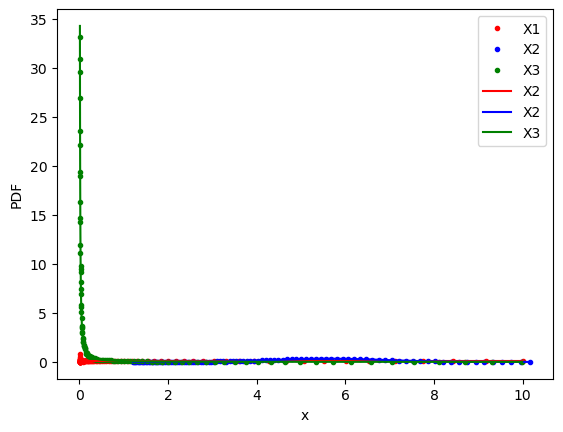

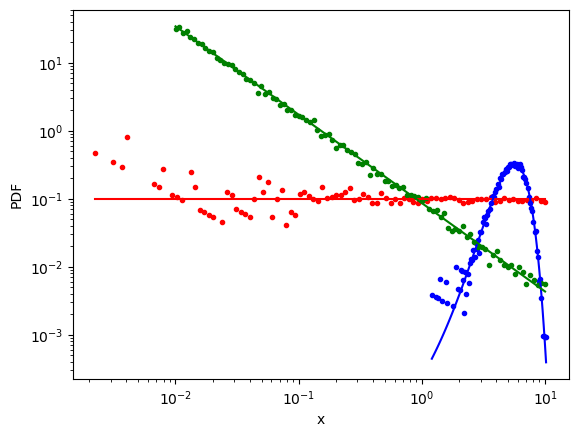

1.0
0.9999999999999999


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform, norm

f1 = 1/(b-a) * np.linspace(1, 1, n)
f2 = 1 / (np.sqrt(2*np.pi)*s) * np.exp(-((x2 - mu))**2 / (2*s**2))
f3 = (1-alpha) / (xmax**(1-alpha) - xmin**(1-alpha)) * x3**(-alpha) 

# Plot
plt.figure(1)
plt.plot(x1, pdf1, 'r.', label='X1')
plt.plot(x2, pdf2, 'b.', label='X2')
plt.plot(x3, pdf3, 'g.', label='X3')
plt.plot(x1, f1, 'r', label='X2')
plt.plot(x2, f2, 'b', label='X2')
plt.plot(x3, f3, 'g', label='X3')

plt.xlabel("x")
plt.ylabel("PDF")

plt.legend()
plt.show()

plt.figure(2)
plt.loglog(x1, pdf1, 'r.')
plt.loglog(x2, pdf2, 'b.')
plt.loglog(x3, pdf3, 'g.')
plt.loglog(x1, f1, 'r')
plt.loglog(x2, f2, 'b')
plt.loglog(x3, f3, 'g')

plt.xlabel("x")
plt.ylabel("PDF")

plt.show()

# verify normalization
print(np.sum(pdf1*dx1))
print(np.sum(pdf2*dx2))

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

av1 = np.sum(x1 * pdf1 * dx1)
std1 = np.sqrt(np.sum((x1 - av1)**2 * pdf1 * dx1))

av2 = np.sum(x2 * pdf2 * dx2)
std2 = np.sqrt(np.sum((x2 - av2)**2 * pdf2 * dx2))

av3 = np.sum(x3 * pdf3 * dx3)
std3 = np.sqrt(np.sum((x3 - av3)**2 * pdf3 * dx3))

av = [av1,av2,av3]
std = [std1,std2,std3]
param1 = [(b+a)/2,mu,(1 - alpha)/(2 - alpha) * (xmax**(2-alpha) - xmin**(2-alpha))/(xmax**(1-alpha) - xmin**(1-alpha))]
param2 = [(b+a)/4,s,np.sqrt((1 - alpha)/(3 - alpha) * (xmax**(3-alpha) - xmin**(3-alpha))/(xmax**(1-alpha) - xmin**(1-alpha)))]
# create dataframe
df = pd.DataFrame({
    "average (g)": av,
    "standard deviation": std,
    "original average": param1,
    "original std": param2
})
df

,average (g),standard deviation,original average,original std
0,5.136098,2.999006,5.000000,2.500000
1,5.616996,1.219823,5.670000,1.230000
2,0.646816,1.573412,0.612343,1.594234
